# 51. Nonlinear optics as a spectrum: the second and third harmonic at every frequency

How much of the light shone on a crystal comes back at twice or three times its frequency,
and how does that change across the spectrum? The second-harmonic susceptibility
$\chi^{(2)}(-2\omega;\omega,\omega)$ and the third-harmonic one
$\chi^{(3)}(-3\omega;\omega,\omega,\omega)$ answer it, and here both come from the steady
state the occupied electrons settle into under a weak oscillating field, solved directly at
each frequency. Nothing is summed over empty bands, so there is no band count to converge,
and nothing is propagated in time, so a frequency costs seconds rather than a run.

The physics of the solve is the one a laser pulse would show: at order $N$ in the field and
harmonic $M$ of it, each occupied state $n$ responds at the complex energy
$\epsilon_n + M\hbar\omega + iN\eta$, with $\eta$ a broadening per photon, and the
response of each order is driven by the one below through the derivatives of the band
Hamiltonian along the field. The current that results at $2\omega$ is the second harmonic,
at $3\omega$ the third.

For zincblende AlAs on a 4x4x4 mesh at 10 Ry, the one independent element of the second
harmonic below the absorption edge, against the sum over states (Quantum ESPRESSO has no
nonlinear optics of this kind; the all-electron code Elk computes the sum over states, which
notebook 33 compares with it):

| $\hbar\omega$ | this route | sum over states, 60 bands |
|---|---|---|
| 0.3 eV | 94.7 + 2.7i pm/V | 94.6 + 2.7i pm/V |
| 1.2 eV | 214.5 + 49.5i | 213.0 + 48.5i |

In [1]:
from pathlib import Path
import numpy as np
from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")
alas = Calculator.from_file(CASES / "alas-raman-wedge.in", PSEUDO, announce=False)
EV = np.linspace(0.2, 3.2, 31)                          # the fundamental photon energy
FIELD = np.ones(3) / np.sqrt(3.0)                       # light polarized along [111]
spectrum = alas.get_nonlinear_spectrum(EV, broadening=0.1, direction=tuple(FIELD), order=2)
xyz = spectrum.chi2(axis=FIELD) * np.sqrt(3.0) / 2.0    # chi_xyz, the one element, pm/V
print(f"chi_xyz at {EV[1]:.1f} eV: {xyz[1].real:.1f} {xyz[1].imag:+.1f}i pm/V")

chi_xyz at 0.3 eV: 94.7 +2.7i pm/V


## Zincblende leaves one number, and the field picks it out

The point group of AlAs, $\bar43m$, leaves a single independent element of
$\chi^{(2)}_{abc}$, the one with three different labels, $\chi_{xyz}$, and every other
element is either equal to it or zero. A field along [111] drives a current along [111] whose
size is $\sum_{abc}e_ae_be_c\,\chi^{abc} = (2/\sqrt3)\,\chi_{xyz}$, which is what the last
line of the cell above undoes. The same calculation along [100] gives nothing at $2\omega$,
because a rotation of the crystal reverses that field.

The spectrum has two edges. A linear absorption starts when one photon reaches the gap; the
second harmonic becomes resonant when two photons do, at half the gap, because the photon
coming out carries $2\hbar\omega$, and the one-photon edge follows at the gap itself.

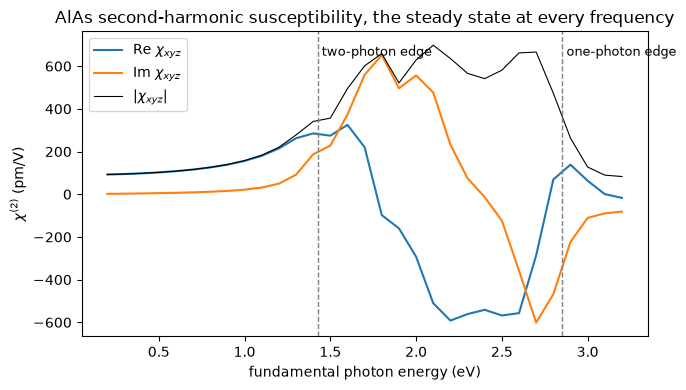

In [2]:
import matplotlib.pyplot as plt

bands = np.asarray(alas.get_scf(nbnd=8).eigenvalues)
gap = float(np.min(bands[:, 4] - bands[:, 3])) * 13.605693   # the direct gap on the mesh, eV
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(EV, xyz.real, label=r"Re $\chi_{xyz}$")
ax.plot(EV, xyz.imag, label=r"Im $\chi_{xyz}$")
ax.plot(EV, np.abs(xyz), "k", lw=0.8, label=r"$|\chi_{xyz}|$")
for edge, name in ((gap / 2, "two-photon edge"), (gap, "one-photon edge")):
    ax.axvline(edge, color="0.5", ls="--", lw=1)
    ax.text(edge, ax.get_ylim()[1] * 0.85, " " + name, fontsize=9)
ax.set_xlabel("fundamental photon energy (eV)")
ax.set_ylabel(r"$\chi^{(2)}$ (pm/V)")
ax.set_title("AlAs second-harmonic susceptibility, the steady state at every frequency")
ax.legend(); fig.tight_layout()

## Against the sum over states

The sum over states builds the same tensor from the interband matrix elements and their
resonances at $\omega$ and $2\omega$, so it needs the empty bands it sums over, and its
conventions differ from the steady state's in two places: it evaluates at
$\omega - i\eta$ where the steady state is at $\omega + i\eta$, and it carries no charge,
to which $\chi^{(2)}$ is odd. The two are related by minus the complex conjugate.

In [3]:
from defumat.system.kpoints import KPoints
from defumat.units import RY_TO_EV

mesh = KPoints.automatic((4, 4, 4), (0, 0, 0), alas.system.cell)
shg = alas.get_shg(kpoints=mesh, nbnd=60, frequencies=EV / RY_TO_EV, broadening=0.1 / RY_TO_EV)
summed = -np.conj(np.asarray(shg.chi)[:, 0, 1, 2])
print(f"{'eV':>5s} {'steady state':>20s} {'sum over states':>20s}")
for i in range(1, 31, 3):
    print(f"{EV[i]:5.1f} {xyz[i].real:10.1f}{xyz[i].imag:+9.1f}i {summed[i].real:10.1f}{summed[i].imag:+9.1f}i")

/u/40/ladovj1/data/Documents/programs/claude/defumat/defumat/workflows/shg.py:139: RuntimeWarning: the band set is cut inside a degenerate multiplet: band_cut_gap = 1.61e-13 Ry, below DEGENERACY_TOL = 1e-08 Ry, the splitting under which two bands are one level. Which members of the multiplet fall below the cut is arbitrary, since any rotation inside it is an equally good set of eigenvectors, so the second-harmonic tensor chi^abc carries a part that is not a property of the crystal: on AlAs (alas-shg.in, the whole 6x6x6 mesh), cut at 22 bands through doublets at 13 of the 216 k-points, rotating each doublet before the cut moves chi^(2) by up to 4.7e-4 of its peak, and the components zincblende forbids read 2.5e-4 of the allowed ones against 1.5e-9 at 23 bands, a clean cut; on two-atom silicon a cut at 12 bands leaves 1095 pm/V where inversion forbids any. Choose an nbnd at which band_cut_gap is a real gap
  return second_harmonic(


   eV         steady state      sum over states
  0.3       94.7     +2.7i       94.6     +2.7i
  0.6      108.1     +6.8i      107.9     +6.7i
  0.9      138.6    +15.6i      138.1    +15.4i
  1.2      214.5    +49.5i      213.0    +48.5i
  1.5      274.4   +227.7i      278.0   +222.7i
  1.8      -97.7   +651.6i      -87.7   +652.3i
  2.1     -510.5   +476.2i     -511.9   +486.3i
  2.4     -541.3    -13.7i     -543.0    -12.7i
  2.7     -286.3   -601.3i     -284.9   -597.4i
  3.0       63.2   -110.6i       60.2   -109.2i


Below the edge the two agree to a few tenths of a per cent with sixty bands, and with 24 they
are 2 to 3 per cent apart: the sum converges in the band count, and not monotonically.
With every band of the sphere, which is more than the band solver can resolve on this small
basis and was built densely offline on the same crystal at 12 Ry, it settles 5 to 9 per cent
short of the steady state, because a sum over states written with the free-electron sum rule leaves out the
curvature of the nonlocal pseudopotential in $\mathbf k$, which the steady state carries;
that the gap is the pseudopotential's was shown by switching the nonlocal part off, where
the two close to $2\times10^{-5}$. So the agreement at sixty bands above is partly a
truncation cancelling part of that term, and the steady state is the complete answer.

## The third harmonic

The same solve to third order gives $\chi^{(3)}$, now with three resonances, at a third of
the gap, half of it and the gap itself.

In [4]:
silicon = Calculator.from_file(CASES / "si2-symmetric.in", PSEUDO, announce=False)
third = silicon.get_nonlinear_spectrum([1.0, 1.55, 2.0], broadening=0.2, direction=(1, 0, 0))
chi_3w, chi_w = third.chi3(axis=0)                      # chi_xxxx(3w) and chi_xxxx(w), m^2/V^2
for w, a, b in zip(third.frequencies, chi_3w, chi_w):
    print(f"{w:4.2f} eV  |chi(3w)| = {abs(a):.2e}   |chi(w; w, w, -w)| = {abs(b):.2e} m^2/V^2")

1.00 eV  |chi(3w)| = 1.38e-17   |chi(w; w, w, -w)| = 2.40e-17 m^2/V^2
1.55 eV  |chi(3w)| = 1.69e-18   |chi(w; w, w, -w)| = 8.28e-18 m^2/V^2
2.00 eV  |chi(3w)| = 3.73e-19   |chi(w; w, w, -w)| = 6.70e-18 m^2/V^2


These are silicon's numbers on its input's 4x4x4 mesh, the same to the digits printed as a
dense solve with every band of the sphere gives there, and they are the mesh's rather than
silicon's: the coupling to a uniform field as a shift of crystal momentum leaves a term in
every order that vanishes only as the mesh converges, and at third order it is as large as
the answer on a coarse mesh. Converged offline at 12 Ry on the meshes from $20^3$ to $28^3$,
at $\eta = 0.2$ eV and 1.55 eV, silicon gives $|\chi^{(3)}_{xxxx}(3\omega)| = 0.66$ and
$|\chi^{(3)}_{xxxx}(-\omega;\omega,\omega,-\omega)| = 0.94$ in units of
$10^{-18}$ m$^2$/V$^2$, against 1.3 and 2.2 from the published LDA calculation of
arXiv:1810.06500, whose potential responds to the field where this one is the ground
state's: the same scale, smaller by about two.


## The linear response, with the potential responding

At first order the potential can respond to the field as well. The field moves charge inside
each cell, that charge has a Hartree and an exchange-correlation potential of its own, and the
states then respond to the field and to that potential together: this is what local fields
are, and their effect on the dielectric function is a shift, which at low frequency has to be
the shift of the static dielectric constant.

In [5]:
lf = silicon.get_nonlinear_spectrum([0.1, 2.0], broadening=0.1, order=1, potential="hxc")
shift = lf.epsilon(0) - lf.epsilon(0, frozen=True)        # the local fields' shift of eps_xx
static = {s: silicon.get_dielectric_tensor(screening=s, born_charges=False).epsilon[0, 0]
          for s in ("none", "full")}
print(f"shift at 0.1 eV: {shift[0].real:+.4f}   static: {static['full'] - static['none']:+.4f}")
print(f"shift at 2.0 eV: {shift[1].real:+.4f} {shift[1].imag:+.4f}i")

shift at 0.1 eV: -0.8834   static: -0.8833
shift at 2.0 eV: -1.5598 -0.1419i


The local fields lower silicon's dielectric constant by about 0.88, 3.7 per cent of 23.8 on
this mesh, and the steady state at 0.1 eV gives the shift the static response gives, which is
a solve of a different kind that shares only the functional with it. At 2 eV the shift is
larger and acquires an absorptive part. The shift and not the dielectric function itself is
what is compared: on a coarse mesh each carries a term from coupling the field as a shift of
crystal momentum that their difference does not.

## What it refuses

The second and third orders are solved at the ground state's potential; with the potential
responding to the field the induced potentials at $2\omega$ and $3\omega$ would each be a
fixed point at every frequency, and that is refused by name (a laser pulse propagated in time
has it, one frequency a run, notebook 50). Magnets, spin-orbit coupling and ultrasoft or PAW
datasets are solved as the propagation solves them (notebook 52), and it refuses a solve that
has not converged, since an unconverged first order is amplified into the second by one over
the broadening.

---
The checks behind this notebook are in `tests/regression/test_realtime_hierarchy.py`, where the
iterative steady state is compared with a dense solve using every band of the sphere and
with the propagation of a pulse at one frequency, and its first order with the potential
responding with a dense self-consistent solve and with the static response, and `tests/regression/test_realtime_shg.py`,
where the second harmonic is compared with the sum over states.